In [1]:
%matplotlib inline

Lets do a simple MLP and build a confusion matrix. Lets build on our mini batch example. Note, I do not train our machine for many epochs.

Training Epoch: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 35/35 [00:00<00:00, 146.32it/s]

Done learning


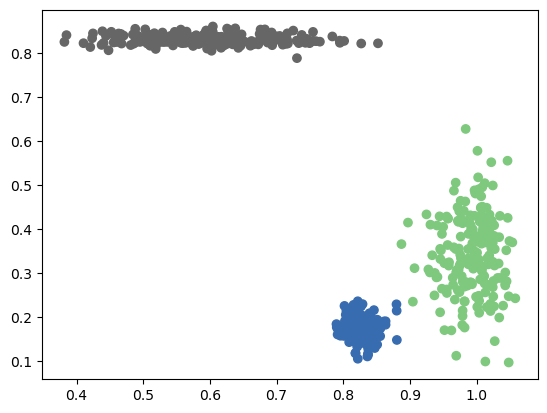

In [2]:
import torch
from tqdm import tqdm
import math
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
from sklearn.cluster import KMeans
from scipy.linalg import lstsq
import sys
import argparse
from torchvision import datasets
import torch.nn as nn

##############################################
# this is our class (look in local directory) for making a PyTorch "dataset" for minibatch
##############################################

from dataset_utils import Format_Dataset

##############################################
# lets define our neural network
##############################################

class MyMLP(torch.nn.Module):

    def forward(self, x):
        y_pred = self.layers(x)
        return y_pred

    def __init__(self, D_in, H1, H2, D_out):
        super(MyMLP, self).__init__()
        self.layers = nn.Sequential(
            nn.Linear(D_in, H1),
            nn.Tanh(),
            nn.Linear(H1,H2),
            nn.Sigmoid(),            
            nn.Linear(H2, D_out),
            nn.Sigmoid()
        )  
        
##############################################
# lets use a random seed so we can get deterministic results run-2-run
##############################################

torch.manual_seed(3527)

##############################################
# dataset
##############################################

# data -----------------------------------
NoSamples = 600
NoPatterns = 3 
x = torch.zeros(NoSamples,2)

# labels ---------------------------------
l = torch.zeros(NoSamples,NoPatterns)
l[0:int(NoSamples/3),0] = 1.0
l[int(NoSamples/3):2*int(NoSamples/3),1] = 1.0
l[2*int(NoSamples/3):,2] = 1.0

# randomly pick our data
Membs = torch.rand(NoPatterns,2) # the means 
Stds = torch.rand(NoPatterns,2)*.1 # the standard deviations 
dc = 0
for r in range(NoPatterns):
    tm = torch.Tensor([Membs[r,0], Membs[r,1]]) 
    tc = torch.eye(2)
    tc[0,0] = Stds[r,0]*Stds[r,0]
    tc[1,1] = Stds[r,1]*Stds[r,1]
    m = torch.distributions.multivariate_normal.MultivariateNormal(tm,tc)
    for i in range(int(NoSamples/NoPatterns)):
        x[dc,:] = m.sample()
        dc = dc + 1

##############################################
# convert this into our PyTorch dataset object
##############################################

# make up training data set
dataset = {'samples': x, 'labels': l} 
train = Format_Dataset(dataset, choice = 'Train')
train.samples = train.samples.to(torch.float32)
train.labels = train.labels.to(torch.float32)
train = torch.utils.data.DataLoader( shuffle = False,
                                        dataset = train, 
                                        batch_size = 30 ) # here is our mini-batch size

##############################################
# create a network and set up optimization
##############################################

D_in, H1, H2, D_out = 2, 16, 16, NoPatterns                                              
net = MyMLP(D_in, H1, H2, D_out)

criterion = torch.nn.BCELoss()
optimizer = torch.optim.Adam(net.parameters(), lr=1e-2)

##############################################
# learning
##############################################

NoEpochs = 35
for epoch in tqdm(range( NoEpochs ),'Training Epoch'):
    for sample, label in train:
        outputs = net(sample)             # this passes in a set of data
        loss = criterion(outputs, label)  # forward pass on set of data
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()            
print('Done learning')

##############################################
# draw
##############################################

L = np.zeros(NoSamples)
L[0:int(NoSamples/NoPatterns)] = 1.0
L[int(NoSamples/NoPatterns):2*int(NoSamples/NoPatterns)] = 2.0
L[2*int(NoSamples/NoPatterns):] = 3.0
plt.scatter(x[:,0], x[:,1], c=L, cmap=plt.cm.Accent)
plt.show()

Evaluation time

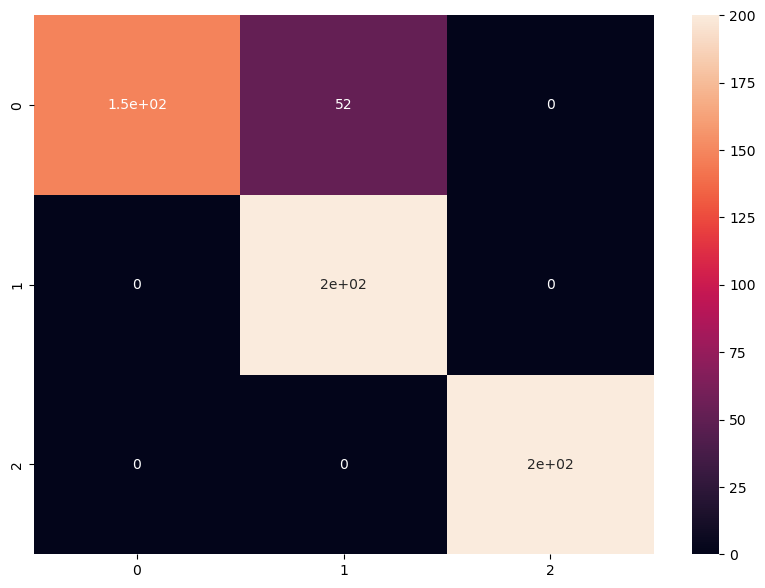

In [3]:
import seaborn as sn  # yes, I had to "conda install seaborn"
import pandas as pd
import matplotlib.pyplot as plt

ConfusionMatrix = torch.zeros((NoPatterns,NoPatterns))
for i in range(NoSamples):
    outputs = net(x[i,:])
    prediction = int(torch.argmax(outputs))
    label = int(torch.argmax(l[i]))
    ConfusionMatrix[label,prediction] = ConfusionMatrix[label,prediction] + 1

df_cm = pd.DataFrame(np.asarray(ConfusionMatrix), index = [i for i in "012"],
                  columns = [i for i in "012"])
plt.figure(figsize = (10,7))
sn.heatmap(df_cm, annot=True)
plt.show()    